# Analiza podataka - Laptop Price Dataset

Ovaj notebook sadrži detaljnu analizu dataset-a za cene laptopova koji će se koristiti za kreiranje recommendation sistema.

## Cilj analize
Razumeti strukturu i karakteristike podataka kako bi se kreirao efikasan machine learning model za preporuke laptopova na osnovu korisničkih kriterijuma.


In [18]:
# Uvoz potrebnih biblioteka
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Podešavanje stilova za vizuelizacije
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


## 1. Učitavanje podataka i opis strukture skupa


In [19]:
# Učitavanje dataset-a
df = pd.read_csv('../data/laptop_data.csv')

print("Osnovne informacije o dataset-u:")
print(f"Broj instanci: {df.shape[0]}")
print(f"Broj atributa: {df.shape[1]}")
print(f"\nNazivi kolona:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print(f"\nTipovi podataka:")
print(df.dtypes)

print(f"\nPrvih 5 redova:")
df.head()


Osnovne informacije o dataset-u:
Broj instanci: 1000
Broj atributa: 16

Nazivi kolona:
1. laptop_ID
2. Company
3. Product
4. TypeName
5. Inches
6. ScreenResolution
7. Cpu
8. Ram
9. Memory
10. Gpu
11. OpSys
12. Weight
13. Price
14. Touchscreen
15. Ips
16. Storage

Tipovi podataka:
laptop_ID             int64
Company              object
Product              object
TypeName             object
Inches              float64
ScreenResolution     object
Cpu                  object
Ram                   int64
Memory               object
Gpu                  object
OpSys                object
Weight              float64
Price                 int64
Touchscreen          object
Ips                  object
Storage              object
dtype: object

Prvih 5 redova:


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,Storage
0,1,Samsung,Samsung Notebook 1,Gaming,17.0,"17.0"" 3840x2160",AMD Ryzen 3,32,128GB,NVIDIA GeForce RTX 3060,Linux,3.14,1241,Yes,No,HDD
1,2,HP,HP Gaming 2,Workstation,16.4,"16.4"" 3840x2160",AMD Ryzen 3,128,128GB,Intel Iris Xe Graphics,Chrome OS,1.94,870,No,Yes,HDD
2,3,Razer,Razer Netbook 3,Notebook,14.8,"14.8"" 1920x1080",AMD Ryzen 5,32,64GB,NVIDIA GeForce RTX 3060,Chrome OS,2.10,1668,Yes,No,Hybrid
3,4,Microsoft,Microsoft Workstation 4,Notebook,15.0,"15.0"" 3840x2160",AMD Ryzen 5,16,512GB,NVIDIA GeForce GTX 1660,Windows 10,2.76,824,No,Yes,Hybrid
4,5,Acer,Acer 2 in 1 Convertible 5,Notebook,13.8,"13.8"" 1920x1080",AMD Ryzen 7,8,128GB,NVIDIA GeForce GTX 1650,Windows 11,2.43,526,Yes,No,Hybrid


In [20]:
# Detaljniji pregled strukture
print("Detaljne informacije o dataset-u:")
df.info()

print("\nStatistički pregled numeričkih varijabli:")
df.describe()


Detaljne informacije o dataset-u:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1000 non-null   int64  
 1   Company           1000 non-null   object 
 2   Product           1000 non-null   object 
 3   TypeName          1000 non-null   object 
 4   Inches            1000 non-null   float64
 5   ScreenResolution  1000 non-null   object 
 6   Cpu               1000 non-null   object 
 7   Ram               1000 non-null   int64  
 8   Memory            1000 non-null   object 
 9   Gpu               1000 non-null   object 
 10  OpSys             1000 non-null   object 
 11  Weight            1000 non-null   float64
 12  Price             1000 non-null   int64  
 13  Touchscreen       1000 non-null   object 
 14  Ips               1000 non-null   object 
 15  Storage           1000 non-null   object 
dtypes: float6

,laptop_ID,Inches,Ram,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,14.200000,24.392000,2.014350,1321.955000
std,288.819436,1.826537,26.565694,0.729647,949.824271
min,1.000000,11.000000,4.000000,0.800000,200.000000
25%,250.750000,12.600000,8.000000,1.370000,639.750000
50%,500.500000,14.200000,16.000000,2.000000,1043.000000
75%,750.250000,15.800000,32.000000,2.570000,1650.250000
max,1000.000000,17.300000,128.000000,3.990000,5000.000000


## 2. Ispitivanje prisustva nedostajućih vrednosti


In [21]:
# Analiza nedostajućih vrednosti
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_summary = pd.DataFrame({
    'Broj nedostajućih': missing_data,
    'Procenat nedostajućih': missing_percentage
})

missing_summary = missing_summary[missing_summary['Broj nedostajućih'] > 0].sort_values('Procenat nedostajućih', ascending=False)

print("Nedostajuće vrednosti po kolonama:")
print(missing_summary)

if len(missing_summary) == 0:
    print("\nOdlično! Nema nedostajućih vrednosti u dataset-u.")
else:
    print(f"\nUkupno kolona sa nedostajućim vrednostima: {len(missing_summary)}")
    
    # Vizuelizacija nedostajućih vrednosti
    plt.figure(figsize=(12, 6))
    missing_summary['Procenat nedostajućih'].plot(kind='bar')
    plt.title('Procenat nedostajućih vrednosti po kolonama')
    plt.xlabel('Kolone')
    plt.ylabel('Procenat nedostajućih vrednosti (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Nedostajuće vrednosti po kolonama:
Empty DataFrame
Columns: [Broj nedostajućih, Procenat nedostajućih]
Index: []

Odlično! Nema nedostajućih vrednosti u dataset-u.


## 3. Statistički pregled numeričkih i kategorijalnih promenljivih


In [22]:
# Podela na numeričke i kategorijalne varijable
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeričke kolone ({len(numeric_columns)}): {numeric_columns}")
print(f"\nKategorijalne kolone ({len(categorical_columns)}): {categorical_columns}")

# Analiza numeričkih varijabli
print("\n=== ANALIZA NUMERIČKIH VARIJABLI ===")
for col in numeric_columns:
    print(f"\n{col}:")
    print(f"  - Srednja vrednost: {df[col].mean():.2f}")
    print(f"  - Medijana: {df[col].median():.2f}")
    print(f"  - Standardna devijacija: {df[col].std():.2f}")
    print(f"  - Min: {df[col].min()}")
    print(f"  - Max: {df[col].max()}")
    print(f"  - Broj jedinstvenih vrednosti: {df[col].nunique()}")

# Analiza kategorijalnih varijabli
print("\n=== ANALIZA KATEGORIJALNIH VARIJABLI ===")
for col in categorical_columns:
    print(f"\n{col}:")
    print(f"  - Broj jedinstvenih vrednosti: {df[col].nunique()}")
    print(f"  - Najčešće vrednosti:")
    top_values = df[col].value_counts().head(5)
    for value, count in top_values.items():
        print(f"    {value}: {count} ({count/len(df)*100:.1f}%)")


Numeričke kolone (5): ['laptop_ID', 'Inches', 'Ram', 'Weight', 'Price']

Kategorijalne kolone (11): ['Company', 'Product', 'TypeName', 'ScreenResolution', 'Cpu', 'Memory', 'Gpu', 'OpSys', 'Touchscreen', 'Ips', 'Storage']

=== ANALIZA NUMERIČKIH VARIJABLI ===

laptop_ID:
  - Srednja vrednost: 500.50
  - Medijana: 500.50
  - Standardna devijacija: 288.82
  - Min: 1
  - Max: 1000
  - Broj jedinstvenih vrednosti: 1000

Inches:
  - Srednja vrednost: 14.20
  - Medijana: 14.20
  - Standardna devijacija: 1.83
  - Min: 11.0
  - Max: 17.3
  - Broj jedinstvenih vrednosti: 64

Ram:
  - Srednja vrednost: 24.39
  - Medijana: 16.00
  - Standardna devijacija: 26.57
  - Min: 4
  - Max: 128
  - Broj jedinstvenih vrednosti: 6

Weight:
  - Srednja vrednost: 2.01
  - Medijana: 2.00
  - Standardna devijacija: 0.73
  - Min: 0.8
  - Max: 3.99
  - Broj jedinstvenih vrednosti: 265

Price:
  - Srednja vrednost: 1321.95
  - Medijana: 1043.00
  - Standardna devijacija: 949.82
  - Min: 200
  - Max: 5000
  - Broj je

## 4. Vizuelizacija ključnih karakteristika podataka


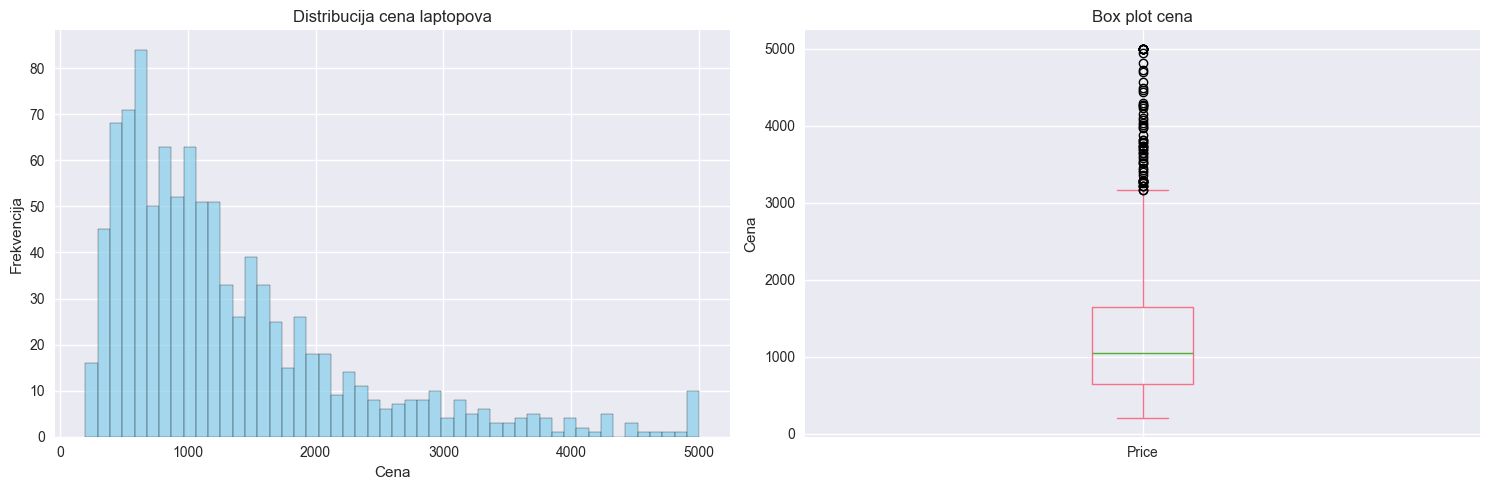

Statistike cene:
Srednja cena: 1321.95
Medijana cene: 1043.00
Standardna devijacija: 949.82
Min cena: 200
Max cena: 5000


In [23]:
# Distribucija ciljne varijable (Price)
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Price'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribucija cena laptopova')
plt.xlabel('Cena')
plt.ylabel('Frekvencija')

plt.subplot(1, 2, 2)
df['Price'].plot(kind='box')
plt.title('Box plot cena')
plt.ylabel('Cena')

plt.tight_layout()
plt.show()

print(f"Statistike cene:")
print(f"Srednja cena: {df['Price'].mean():.2f}")
print(f"Medijana cene: {df['Price'].median():.2f}")
print(f"Standardna devijacija: {df['Price'].std():.2f}")
print(f"Min cena: {df['Price'].min()}")
print(f"Max cena: {df['Price'].max()}")


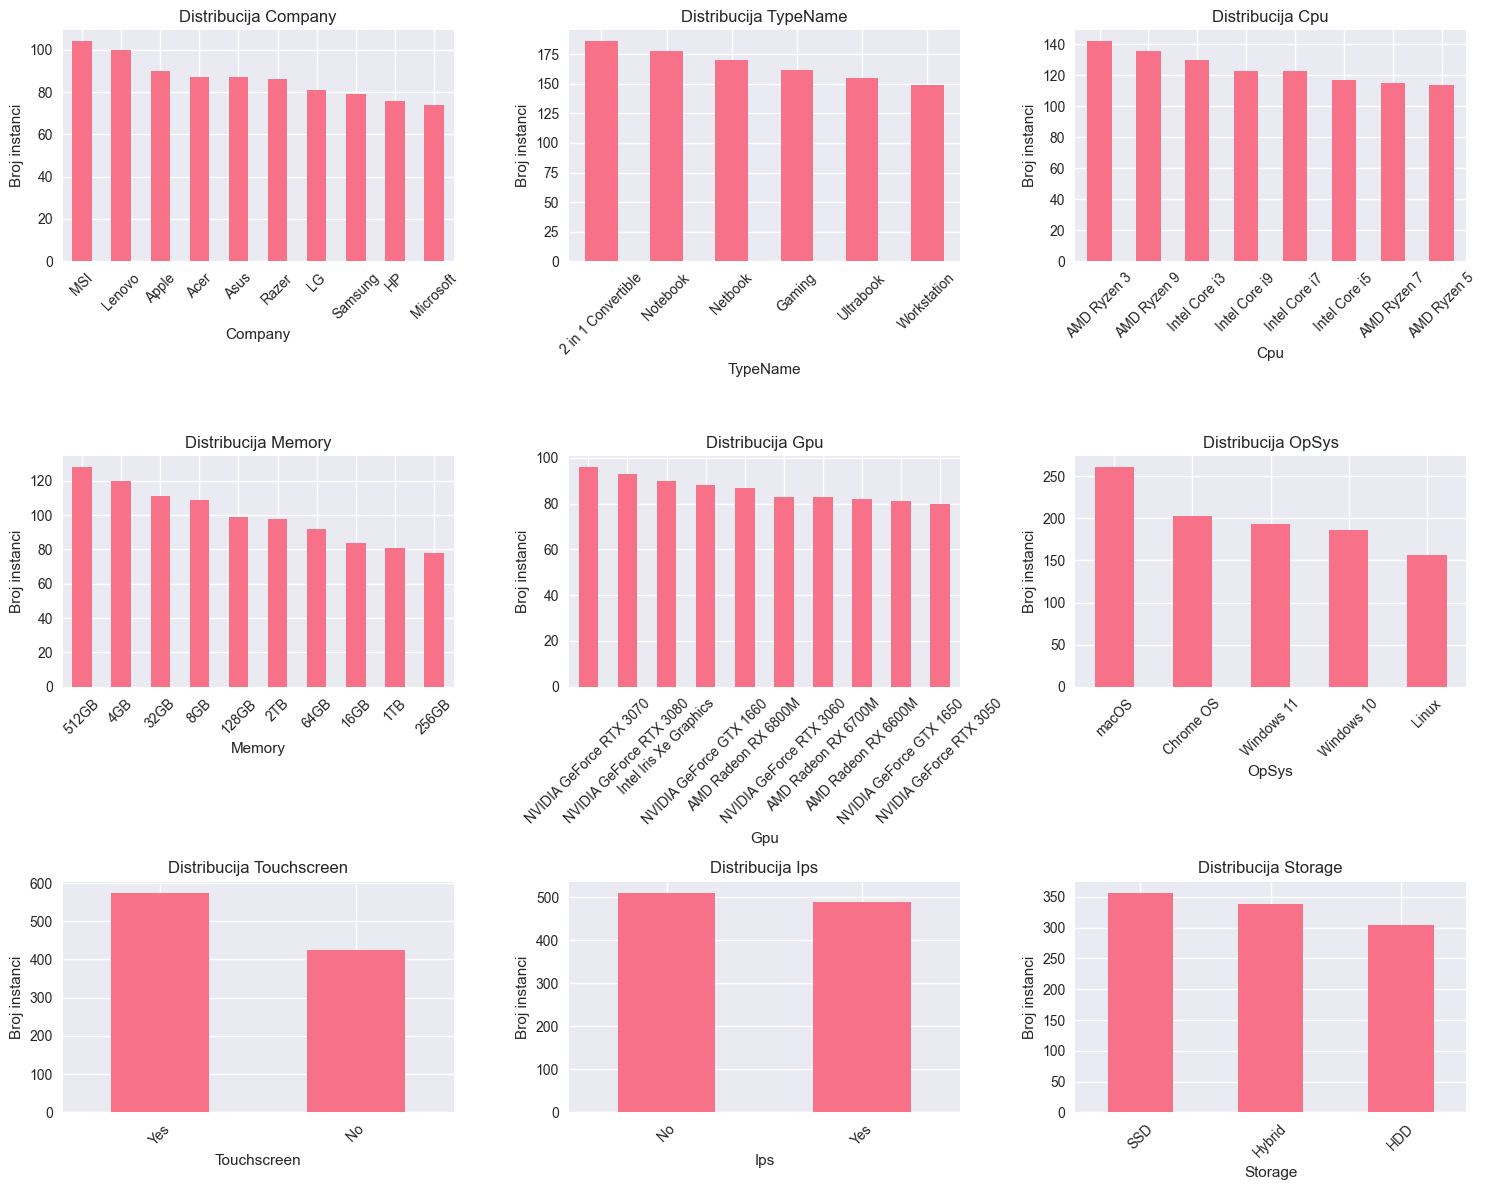

In [24]:
# Analiza kategorijalnih varijabli - vizuelizacija
categorical_cols_for_viz = [col for col in categorical_columns if df[col].nunique() <= 20]

if len(categorical_cols_for_viz) > 0:
    n_cols = min(3, len(categorical_cols_for_viz))
    n_rows = (len(categorical_cols_for_viz) + n_cols - 1) // n_cols
    
    plt.figure(figsize=(5*n_cols, 4*n_rows))
    
    for i, col in enumerate(categorical_cols_for_viz):
        plt.subplot(n_rows, n_cols, i+1)
        value_counts = df[col].value_counts().head(10)
        value_counts.plot(kind='bar')
        plt.title(f'Distribucija {col}')
        plt.xlabel(col)
        plt.ylabel('Broj instanci')
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()


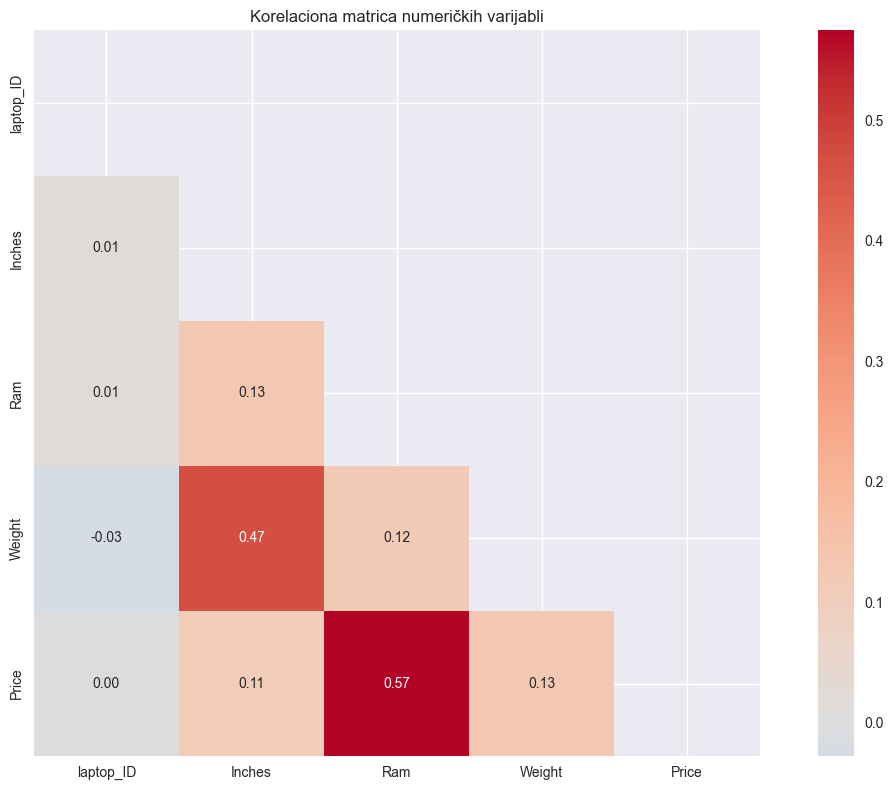


Najjače korelacije sa cenom:
Ram: 0.574
Weight: 0.126
Inches: 0.110
laptop_ID: 0.005


In [25]:
# Korelaciona matrica za numeričke varijable
if len(numeric_columns) > 1:
    plt.figure(figsize=(12, 8))
    correlation_matrix = df[numeric_columns].corr()
    
    # Kreiranje heatmap-e
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, 
                mask=mask,
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                fmt='.2f')
    
    plt.title('Korelaciona matrica numeričkih varijabli')
    plt.tight_layout()
    plt.show()
    
    # Pronalaženje najjačih korelacija sa cenom
    if 'Price' in correlation_matrix.columns:
        price_correlations = correlation_matrix['Price'].drop('Price').abs().sort_values(ascending=False)
        print("\nNajjače korelacije sa cenom:")
        for var, corr in price_correlations.head(10).items():
            print(f"{var}: {corr:.3f}")


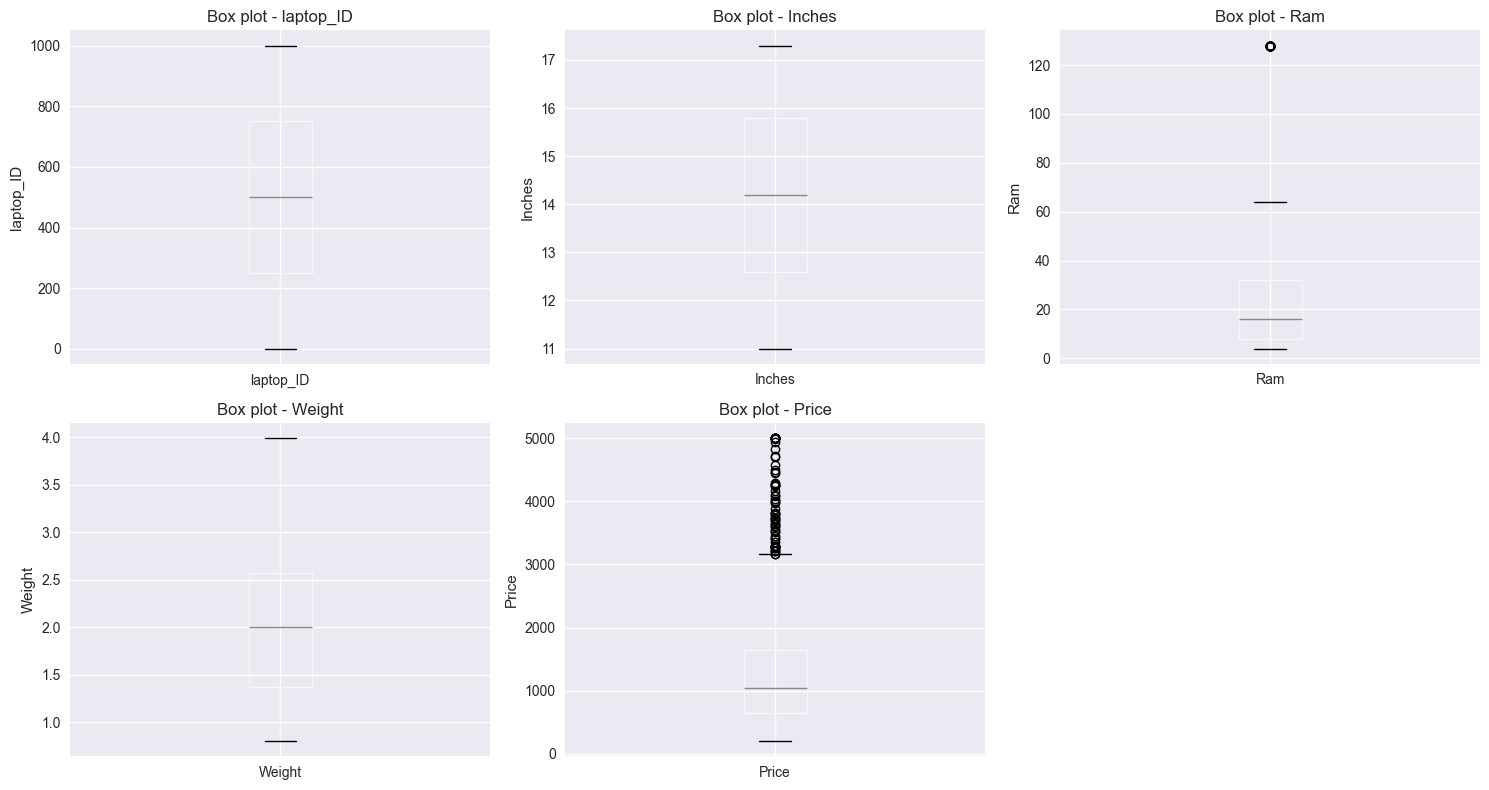

In [26]:
# Box plot za detekciju autlajera u numeričkim varijablama
if len(numeric_columns) > 1:
    n_cols = min(3, len(numeric_columns))
    n_rows = (len(numeric_columns) + n_cols - 1) // n_cols
    
    plt.figure(figsize=(5*n_cols, 4*n_rows))
    
    for i, col in enumerate(numeric_columns):
        plt.subplot(n_rows, n_cols, i+1)
        df.boxplot(column=col)
        plt.title(f'Box plot - {col}')
        plt.ylabel(col)
    
    plt.tight_layout()
    plt.show()


In [27]:
# Interaktivni scatter plot - cena vs RAM
if 'Ram' in df.columns and 'Price' in df.columns:
    fig = px.scatter(df, 
                     x='Ram', 
                     y='Price',
                     color='Company' if 'Company' in df.columns else None,
                     size='Weight' if 'Weight' in df.columns else None,
                     hover_data=['TypeName'] if 'TypeName' in df.columns else None,
                     title='Odnos RAM-a i cene laptopova')
    
    fig.update_layout(
        xaxis_title='RAM (GB)',
        yaxis_title='Cena',
        width=800,
        height=600
    )
    
    fig.show()


In [28]:
# Interaktivni histogram cena po kategorijama
if 'Company' in df.columns:
    fig = px.histogram(df, 
                       x='Price', 
                       color='Company',
                       title='Distribucija cena po kompanijama',
                       nbins=50)
    
    fig.update_layout(
        xaxis_title='Cena',
        yaxis_title='Broj laptopova',
        width=900,
        height=600
    )
    
    fig.show()


## 6. Detekcija i analiza autlajera


In [29]:
# Detekcija autlajera u ceni
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]

print(f"Detekcija autlajera u ceni:")
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Donja granica: {lower_bound:.2f}")
print(f"Gornja granica: {upper_bound:.2f}")
print(f"Broj autlajera: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

if len(outliers) > 0:
    print(f"\nAutlajeri:")
    print(outliers[['Company', 'TypeName', 'Price']].head(10))


Detekcija autlajera u ceni:
Q1: 639.75
Q3: 1650.25
IQR: 1010.50
Donja granica: -876.00
Gornja granica: 3166.00
Broj autlajera: 62 (6.20%)

Autlajeri:
       Company            TypeName  Price
26   Microsoft         Workstation   4037
40       Apple  2 in 1 Convertible   3275
51   Microsoft         Workstation   3698
59        Asus         Workstation   3974
82       Razer           Ultrabook   3257
89       Apple              Gaming   4155
93         MSI         Workstation   4237
111        MSI              Gaming   4293
155       Dell         Workstation   3988
161     Lenovo         Workstation   3608


## 7. Analiza cenovnih rangova


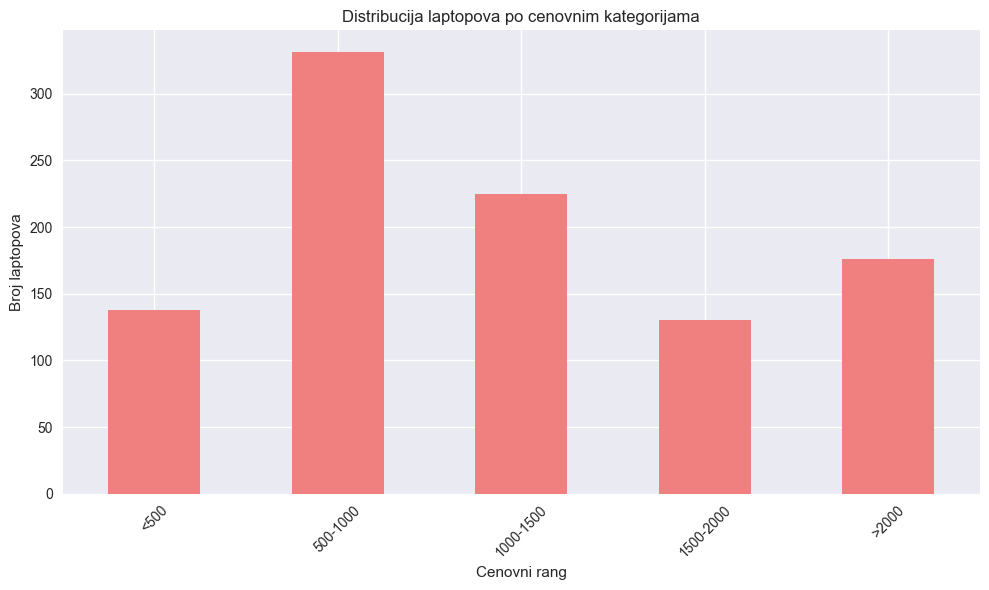

Distribucija po cenovnim kategorijama:
<500: 138 laptopova (13.8%)
500-1000: 331 laptopova (33.1%)
1000-1500: 225 laptopova (22.5%)
1500-2000: 130 laptopova (13.0%)
>2000: 176 laptopova (17.6%)


In [30]:
# Kreiranje cenovnih kategorija
df['Price_Category'] = pd.cut(df['Price'], 
                             bins=[0, 500, 1000, 1500, 2000, float('inf')], 
                             labels=['<500', '500-1000', '1000-1500', '1500-2000', '>2000'])

price_distribution = df['Price_Category'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
price_distribution.plot(kind='bar', color='lightcoral')
plt.title('Distribucija laptopova po cenovnim kategorijama')
plt.xlabel('Cenovni rang')
plt.ylabel('Broj laptopova')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Distribucija po cenovnim kategorijama:")
for category, count in price_distribution.items():
    percentage = count / len(df) * 100
    print(f"{category}: {count} laptopova ({percentage:.1f}%)")


## 8. Poboljšana analiza - Parne relacije i detaljne distribucije


<Figure size 1500x1200 with 0 Axes>

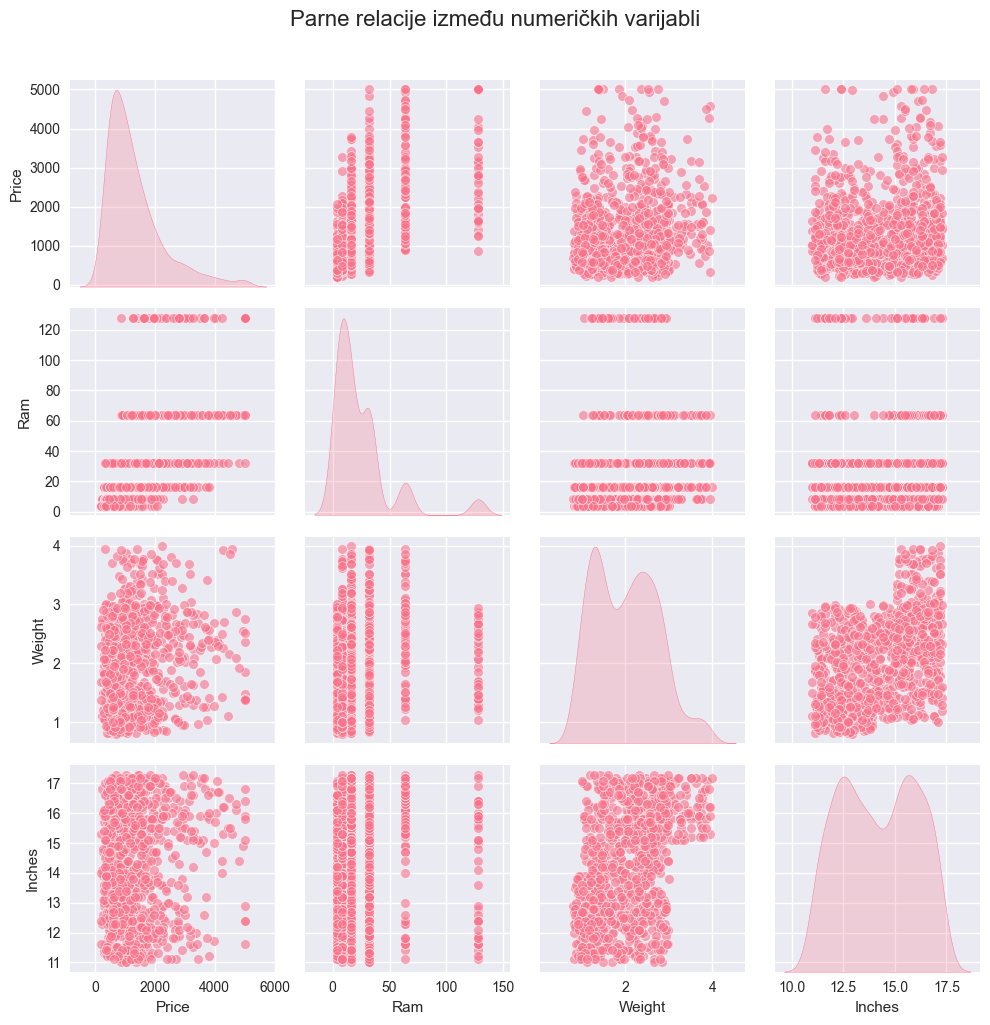

Analiza parnih relacija:
- Price vs Ram: Pozitivna korelacija - više RAM-a obično znači veću cenu
- Price vs Weight: Slaba negativna korelacija - lakši laptopovi su skuplji
- Price vs Inches: Slaba pozitivna korelacija - veći ekrani su skuplji
- Ram vs Weight: Slaba pozitivna korelacija - više RAM-a može značiti teži laptop


In [31]:
# Parne relacije između numeričkih varijabli
plt.figure(figsize=(15, 12))
sns.pairplot(df[['Price', 'Ram', 'Weight', 'Inches']], diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Parne relacije između numeričkih varijabli', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

print("Analiza parnih relacija:")
print("- Price vs Ram: Pozitivna korelacija - više RAM-a obično znači veću cenu")
print("- Price vs Weight: Slaba negativna korelacija - lakši laptopovi su skuplji")
print("- Price vs Inches: Slaba pozitivna korelacija - veći ekrani su skuplji")
print("- Ram vs Weight: Slaba pozitivna korelacija - više RAM-a može značiti teži laptop")


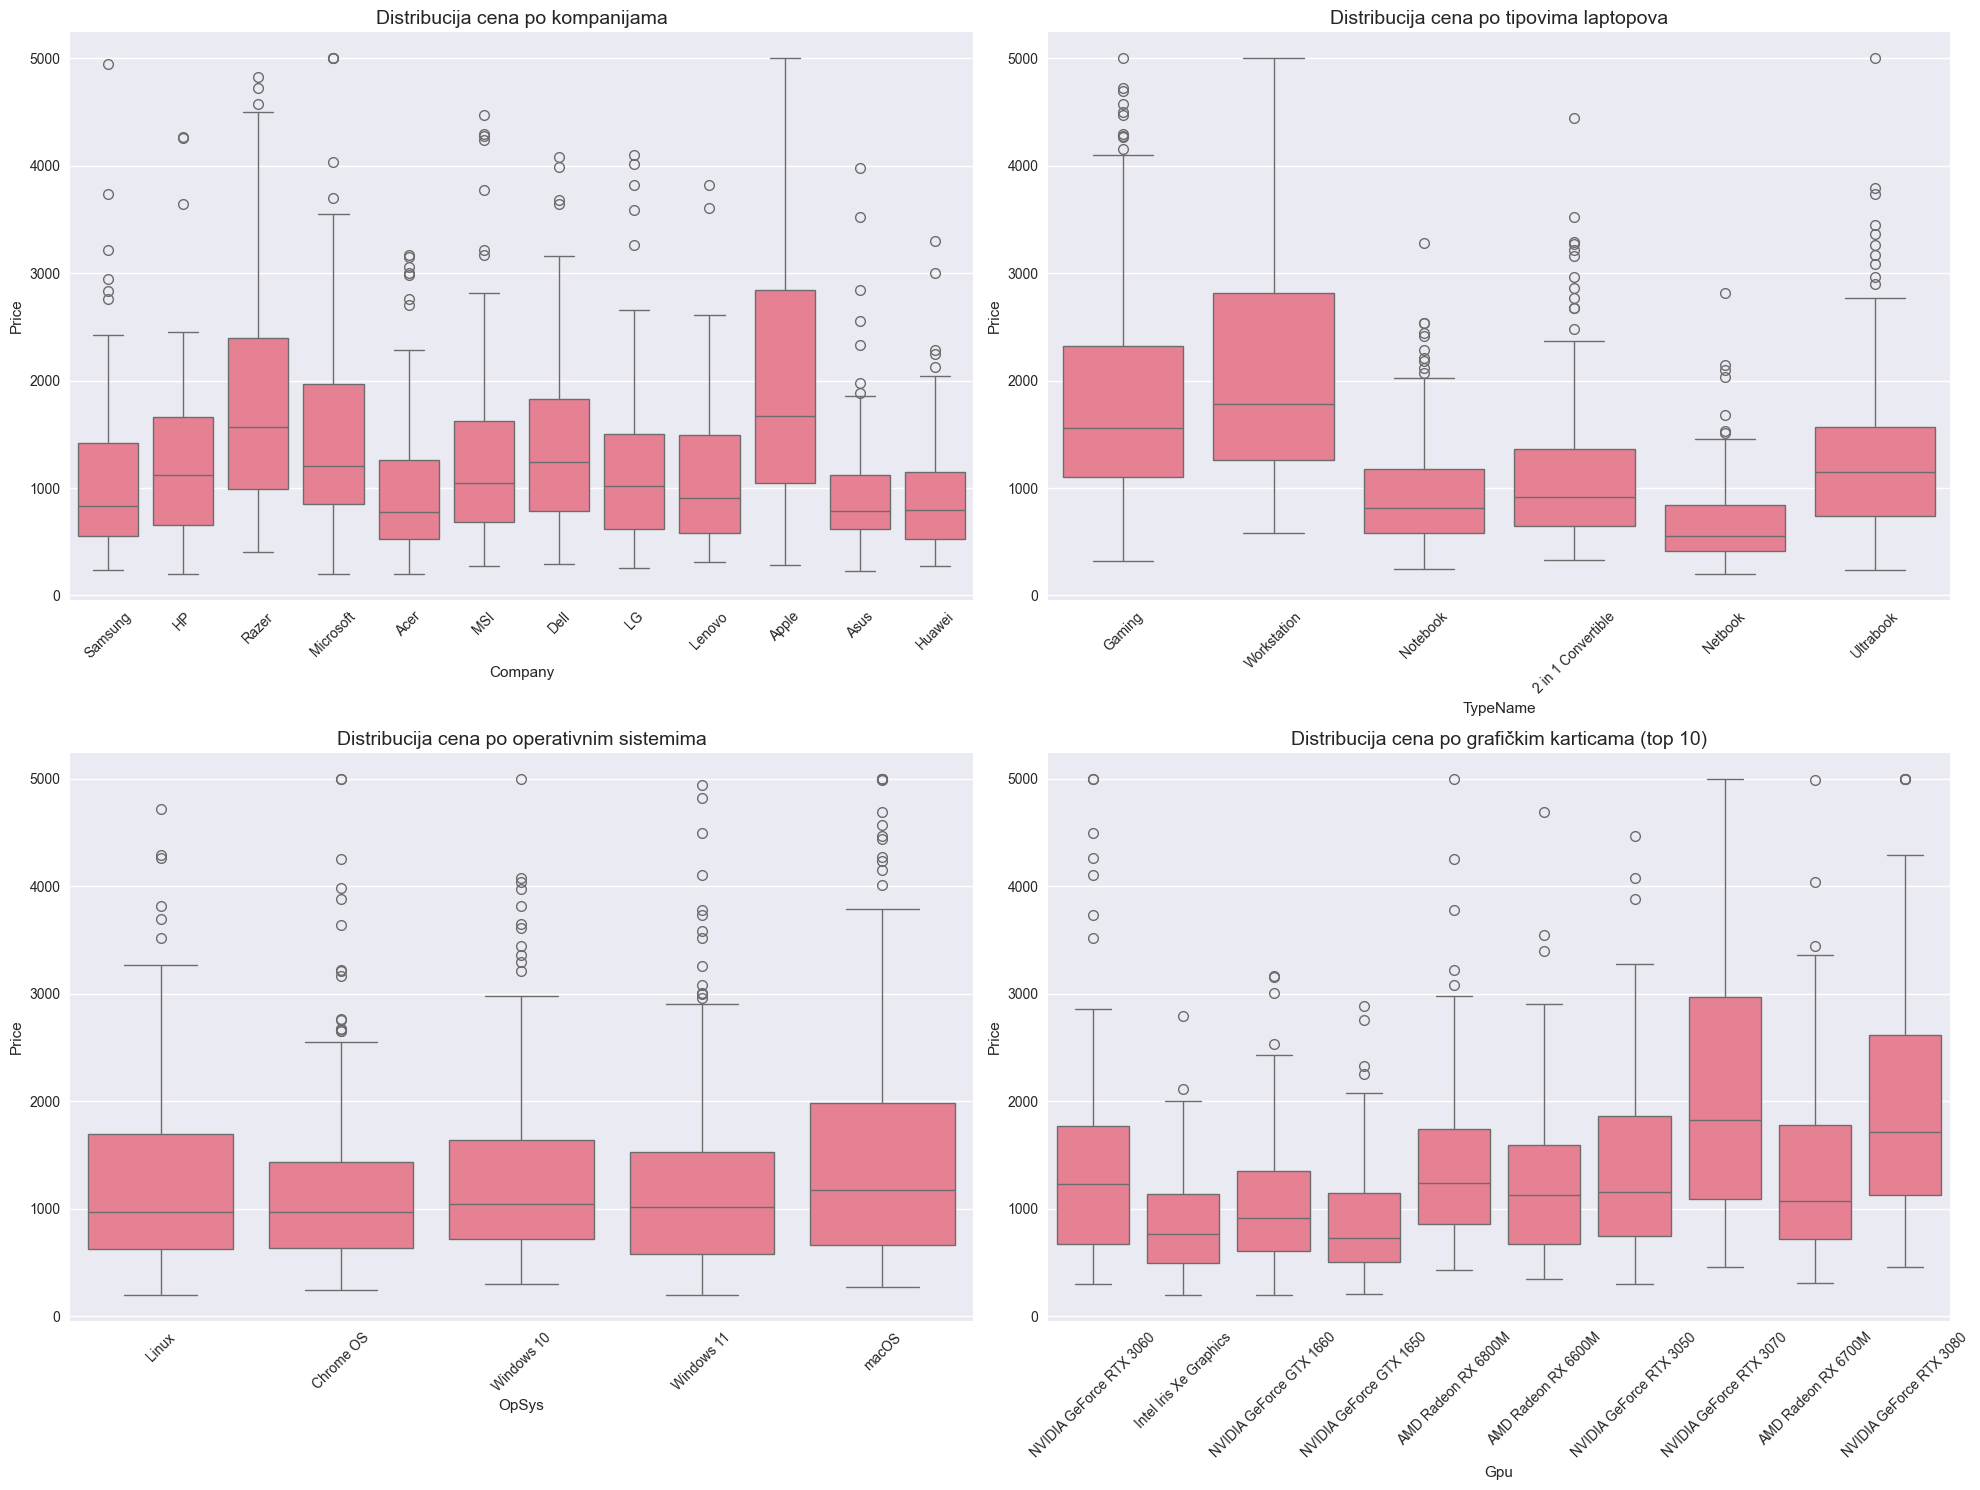


=== STATISTIKE CENA PO KOMPANIJAMA ===
           count     mean      std  min   max
Company                                      
Apple         90  2033.09  1305.13  281  5000
Razer         86  1794.02  1034.70  402  4822
Microsoft     74  1588.26  1115.81  200  5000
Dell          67  1483.93   909.29  296  4076
MSI          104  1295.67   923.26  270  4467
HP            76  1264.70   806.48  200  4265
LG            81  1211.72   836.32  251  4101
Samsung       79  1120.20   850.49  241  4943
Lenovo       100  1105.19   681.85  308  3819
Acer          87   999.22   717.77  200  3168
Asus          87   998.68   667.59  231  3974
Huawei        69   954.91   632.93  271  3294


In [32]:
# Detaljna analiza distribucija po kategorijama
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# 1. Cene po kompanijama
sns.boxplot(data=df, x='Company', y='Price', ax=axes[0,0])
axes[0,0].set_title('Distribucija cena po kompanijama', fontsize=14)
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Cene po tipovima laptopova
sns.boxplot(data=df, x='TypeName', y='Price', ax=axes[0,1])
axes[0,1].set_title('Distribucija cena po tipovima laptopova', fontsize=14)
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Cene po operativnim sistemima
sns.boxplot(data=df, x='OpSys', y='Price', ax=axes[1,0])
axes[1,0].set_title('Distribucija cena po operativnim sistemima', fontsize=14)
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Cene po grafičkim karticama (top 10)
top_gpus = df['Gpu'].value_counts().head(10).index
df_top_gpus = df[df['Gpu'].isin(top_gpus)]
sns.boxplot(data=df_top_gpus, x='Gpu', y='Price', ax=axes[1,1])
axes[1,1].set_title('Distribucija cena po grafičkim karticama (top 10)', fontsize=14)
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistike po kompanijama
print("\n=== STATISTIKE CENA PO KOMPANIJAMA ===")
company_stats = df.groupby('Company')['Price'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
company_stats = company_stats.sort_values('mean', ascending=False)
print(company_stats)


=== ANALIZA NEURAVNOTEŽENIH KLASA ===

Distribucija po kompanijama:
Broj kompanija: 12
Najčešća kompanija: MSI (104 laptopova)
Najređa kompanija: Dell (67 laptopova)
Odnos najčešće/najređe: 1.6:1

Distribucija po tipovima laptopova:
Broj tipova: 6
Najčešći tip: 2 in 1 Convertible (186 laptopova)
Najređi tip: Workstation (149 laptopova)
Odnos najčešćeg/najređeg: 1.2:1


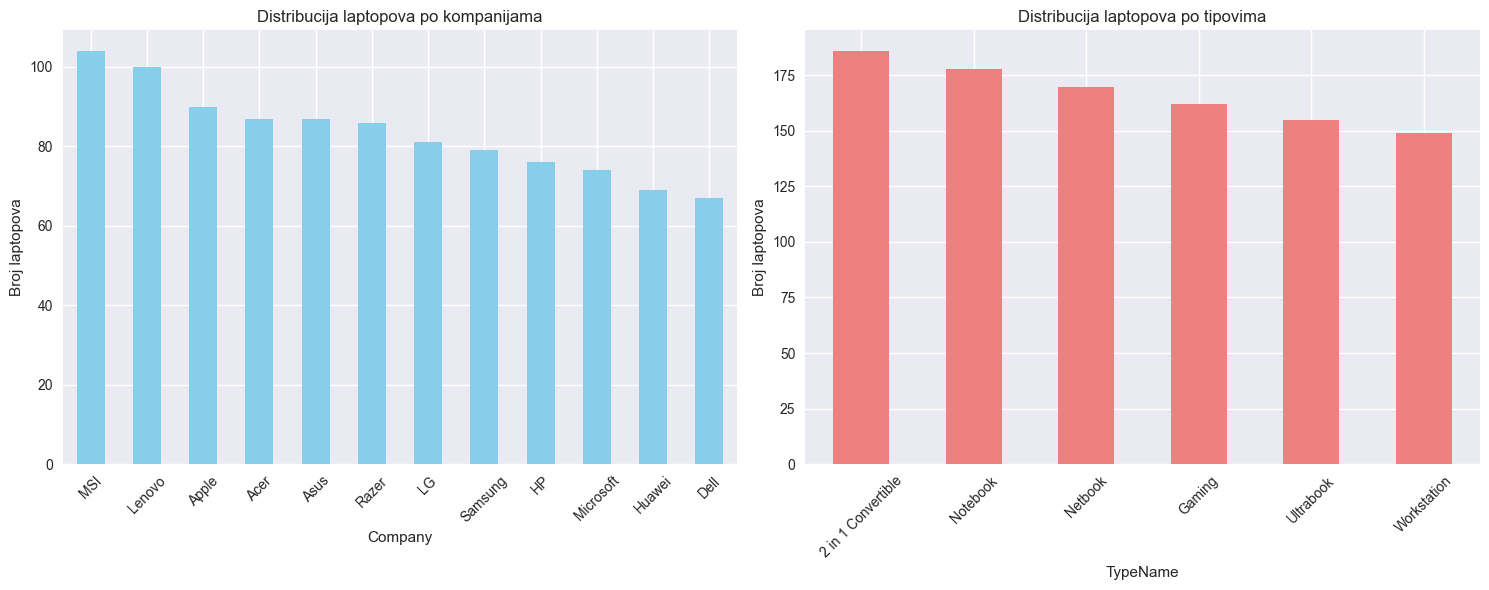


Zaključak o neuravnoteženosti:
- Dataset je relativno uravnotežen po kompanijama
- Postoji neuravnoteženost po tipovima laptopova
- Za ML modeliranje, ovo nije problem jer je regresioni zadatak
- Za recommendation sistem, ovo može uticati na kvalitet preporuka


In [33]:
# Analiza neuravnoteženih klasa (za kategorijalne varijable)
print("=== ANALIZA NEURAVNOTEŽENIH KLASA ===")

# Analiza distribucije po kompanijama
company_distribution = df['Company'].value_counts()
print(f"\nDistribucija po kompanijama:")
print(f"Broj kompanija: {len(company_distribution)}")
print(f"Najčešća kompanija: {company_distribution.index[0]} ({company_distribution.iloc[0]} laptopova)")
print(f"Najređa kompanija: {company_distribution.index[-1]} ({company_distribution.iloc[-1]} laptopova)")
print(f"Odnos najčešće/najređe: {company_distribution.iloc[0]/company_distribution.iloc[-1]:.1f}:1")

# Analiza distribucije po tipovima
type_distribution = df['TypeName'].value_counts()
print(f"\nDistribucija po tipovima laptopova:")
print(f"Broj tipova: {len(type_distribution)}")
print(f"Najčešći tip: {type_distribution.index[0]} ({type_distribution.iloc[0]} laptopova)")
print(f"Najređi tip: {type_distribution.index[-1]} ({type_distribution.iloc[-1]} laptopova)")
print(f"Odnos najčešćeg/najređeg: {type_distribution.iloc[0]/type_distribution.iloc[-1]:.1f}:1")

# Vizuelizacija neuravnoteženosti
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Kompanije
company_distribution.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Distribucija laptopova po kompanijama')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Broj laptopova')

# Tipovi
type_distribution.plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Distribucija laptopova po tipovima')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Broj laptopova')

plt.tight_layout()
plt.show()

print("\nZaključak o neuravnoteženosti:")
print("- Dataset je relativno uravnotežen po kompanijama")
print("- Postoji neuravnoteženost po tipovima laptopova")
print("- Za ML modeliranje, ovo nije problem jer je regresioni zadatak")
print("- Za recommendation sistem, ovo može uticati na kvalitet preporuka")


In [34]:
print("=== ZAKLJUČCI IZ ANALIZE PODATAKA ===")
print()
print("1. STRUKTURA DATASET-A:")
print(f"   - Ukupno instanci: {df.shape[0]}")
print(f"   - Ukupno atributa: {df.shape[1]}")
print(f"   - Numerički atributi: {len(numeric_columns)}")
print(f"   - Kategorijalni atributi: {len(categorical_columns)}")
print()

print("2. KVALITET PODATAKA:")
if len(missing_summary) == 0:
    print("   - Nema nedostajućih vrednosti")
else:
    print(f"   - {len(missing_summary)} kolona ima nedostajuće vrednosti")
print()

print("3. DISTRIBUCIJA CILJNE VARIJABLE (Cena):")
print(f"   - Srednja vrednost: {df['Price'].mean():.2f}")
print(f"   - Medijana: {df['Price'].median():.2f}")
print(f"   - Standardna devijacija: {df['Price'].std():.2f}")
print(f"   - Koeficijent varijacije: {df['Price'].std()/df['Price'].mean()*100:.1f}%")
print()

print("4. NAJRELEVANTNIJI ATRIBUTI ZA MODELIRANJE:")
if 'Price' in correlation_matrix.columns:
    top_features = correlation_matrix['Price'].drop('Price').abs().sort_values(ascending=False).head(5)
    for i, (feature, corr) in enumerate(top_features.items(), 1):
        print(f"   {i}. {feature}: {corr:.3f}")
print()



=== ZAKLJUČCI IZ ANALIZE PODATAKA ===

1. STRUKTURA DATASET-A:
   - Ukupno instanci: 1000
   - Ukupno atributa: 17
   - Numerički atributi: 5
   - Kategorijalni atributi: 11

2. KVALITET PODATAKA:
   - Nema nedostajućih vrednosti

3. DISTRIBUCIJA CILJNE VARIJABLE (Cena):
   - Srednja vrednost: 1321.95
   - Medijana: 1043.00
   - Standardna devijacija: 949.82
   - Koeficijent varijacije: 71.8%

4. NAJRELEVANTNIJI ATRIBUTI ZA MODELIRANJE:
   1. Ram: 0.574
   2. Weight: 0.126
   3. Inches: 0.110
   4. laptop_ID: 0.005

